In [1]:
# ============================================
# 1 ИМПОРТЫ БИБЛИОТЕК
# ============================================

import os
import time
import copy
import shutil
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models, transforms
from torchvision.models import vgg16, vgg16_bn, efficientnet_b0, mobilenet_v3_small
from PIL import Image

# Настройка стиля графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

In [2]:
# ============================================
# 2 НАСТРОЙКА ПУТЕЙ И УСТРОЙСТВА
# ============================================

# Локальная машина Windows: используем указанный путь
BASE_DIR = r'F:/Jupiter/HW_Simpsons/archive'
TRAIN_DIR = os.path.join(BASE_DIR, 'simpsons_dataset/')
TEST_DIR = os.path.join(BASE_DIR, 'kaggle_simpson_testset/')
WEIGHTS_PATH = os.path.join(BASE_DIR, 'weights.best.hdf5')

# Дополнительные файлы
CSV_PATH = os.path.join(BASE_DIR, 'number_pic_char.csv')
CHAR_IMG_PATH = os.path.join(BASE_DIR, 'characters_illustration.png')
ANNOTATION_PATH = os.path.join(BASE_DIR, 'annotation.txt')

# Директория для чекпоинтов
CHECKPOINT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Проверка путей
paths_to_check = [
    ('TRAIN_DIR', TRAIN_DIR),
    ('TEST_DIR', TEST_DIR),
    ('CHECKPOINT_DIR', CHECKPOINT_DIR),
]
for name, p in paths_to_check:
    print(f'{name}: {p} -> exists: {os.path.exists(p)}')

# Настройки устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

TRAIN_DIR: F:/Jupiter/HW_Simpsons/archive\simpsons_dataset/ -> exists: True
TEST_DIR: F:/Jupiter/HW_Simpsons/archive\kaggle_simpson_testset/ -> exists: True
CHECKPOINT_DIR: F:/Jupiter/HW_Simpsons/archive\checkpoints -> exists: True

Using device: cuda
GPU: NVIDIA GeForce RTX 3060
Memory: 12.88 GB


In [3]:
# ============================================
# 3 МОДУЛЬ ЧЕКПОИНТОВ
# ============================================

def save_checkpoint(model, optimizer, scheduler, epoch, history, best_acc, 
                   best_model_wts, experiment_name, filename=None):
    """
    Сохраняет чекпоинт обучения
    """
    if filename is None:
        filename = f'checkpoint_{experiment_name}_epoch{epoch+1}.pt'
    
    checkpoint_path = os.path.join(CHECKPOINT_DIR, filename)
    
    # Безопасное сохранение scheduler state
    scheduler_state = None
    if scheduler is not None:
        try:
            scheduler_state = scheduler.state_dict()
        except Exception as e:
            print(f"⚠️  Не удалось сохранить состояние scheduler: {e}")
    
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler_state,
        'history': history,
        'best_acc': best_acc,
        'best_model_wts': best_model_wts,
        'experiment_name': experiment_name,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    try:
        torch.save(checkpoint, checkpoint_path)
        # Также сохраняем последний чекпоинт как 'latest'
        latest_path = os.path.join(CHECKPOINT_DIR, f'latest_{experiment_name}.pt')
        shutil.copy2(checkpoint_path, latest_path)
        print(f"💾 Чекпоинт сохранён: {checkpoint_path}")
        return checkpoint_path
    except Exception as e:
        print(f"❌ Ошибка при сохранении чекпоинта: {e}")
        return None


def load_checkpoint(checkpoint_path, model, optimizer, scheduler=None):
    """
    Загружает чекпоинт обучения с обработкой ошибок
    """
    if not os.path.exists(checkpoint_path):
        return None
    
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        
        # Загружаем состояние модели
        model.load_state_dict(checkpoint['model_state_dict'])
        
        # Загружаем состояние оптимизатора
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
        # Загружаем состояние scheduler если возможно
        if scheduler is not None and checkpoint['scheduler_state_dict'] is not None:
            try:
                scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            except Exception as e:
                print(f"⚠️  Не удалось загрузить состояние scheduler: {e}")
        
        print(f"✅ Чекпоинт загружён: {checkpoint_path}")
        print(f"   Эпоха: {checkpoint['epoch'] + 1}")
        print(f"   Лучшая точность: {checkpoint['best_acc']:.4f}")
        print(f"   Время сохранения: {checkpoint['timestamp']}")
        
        return checkpoint
    except Exception as e:
        print(f"❌ Ошибка при загрузке чекпоинта: {e}")
        return None


def find_latest_checkpoint(experiment_name):
    """
    Находит последний чекпоинт для эксперимента
    """
    # Сначала проверяем 'latest' файл
    latest_path = os.path.join(CHECKPOINT_DIR, f'latest_{experiment_name}.pt')
    if os.path.exists(latest_path):
        return latest_path
    
    # Ищем среди всех файлов
    pattern = f'checkpoint_{experiment_name}'
    checkpoints = []
    
    for filename in os.listdir(CHECKPOINT_DIR):
        if filename.startswith(pattern) and filename.endswith('.pt'):
            filepath = os.path.join(CHECKPOINT_DIR, filename)
            checkpoints.append((filepath, os.path.getmtime(filepath)))
    
    if checkpoints:
        # Сортируем по времени модификации, берем последний
        checkpoints.sort(key=lambda x: x[1], reverse=True)
        return checkpoints[0][0]
    
    return None


def list_checkpoints():
    """
    Выводит список всех доступных чекпоинтов
    """
    print("\n" + "="*70)
    print("📁 ДОСТУПНЫЕ ЧЕКПОИНТЫ")
    print("="*70)
    
    if not os.path.exists(CHECKPOINT_DIR):
        print("❌ Директория чекпоинтов не существует")
        return
    
    checkpoints = []
    for filename in os.listdir(CHECKPOINT_DIR):
        if filename.endswith('.pt'):
            filepath = os.path.join(CHECKPOINT_DIR, filename)
            size_mb = os.path.getsize(filepath) / (1024 * 1024)
            mtime = datetime.fromtimestamp(os.path.getmtime(filepath))
            checkpoints.append((filename, size_mb, mtime))
    
    if checkpoints:
        # Сортируем по времени
        checkpoints.sort(key=lambda x: x[2], reverse=True)
        for filename, size, mtime in checkpoints:
            print(f"  📄 {filename:50s} | {size:>6.2f} MB | {mtime}")
    else:
        print("  📭 Чекпоинты не найдены")
    
    print("="*70)

✅ Аугментации успешно определены!
   Good: 6 трансформаций
   Bad: 9 трансформаций
   Very Bad: 11 трансформаций
🖼️ Генерация детальной визуализации...


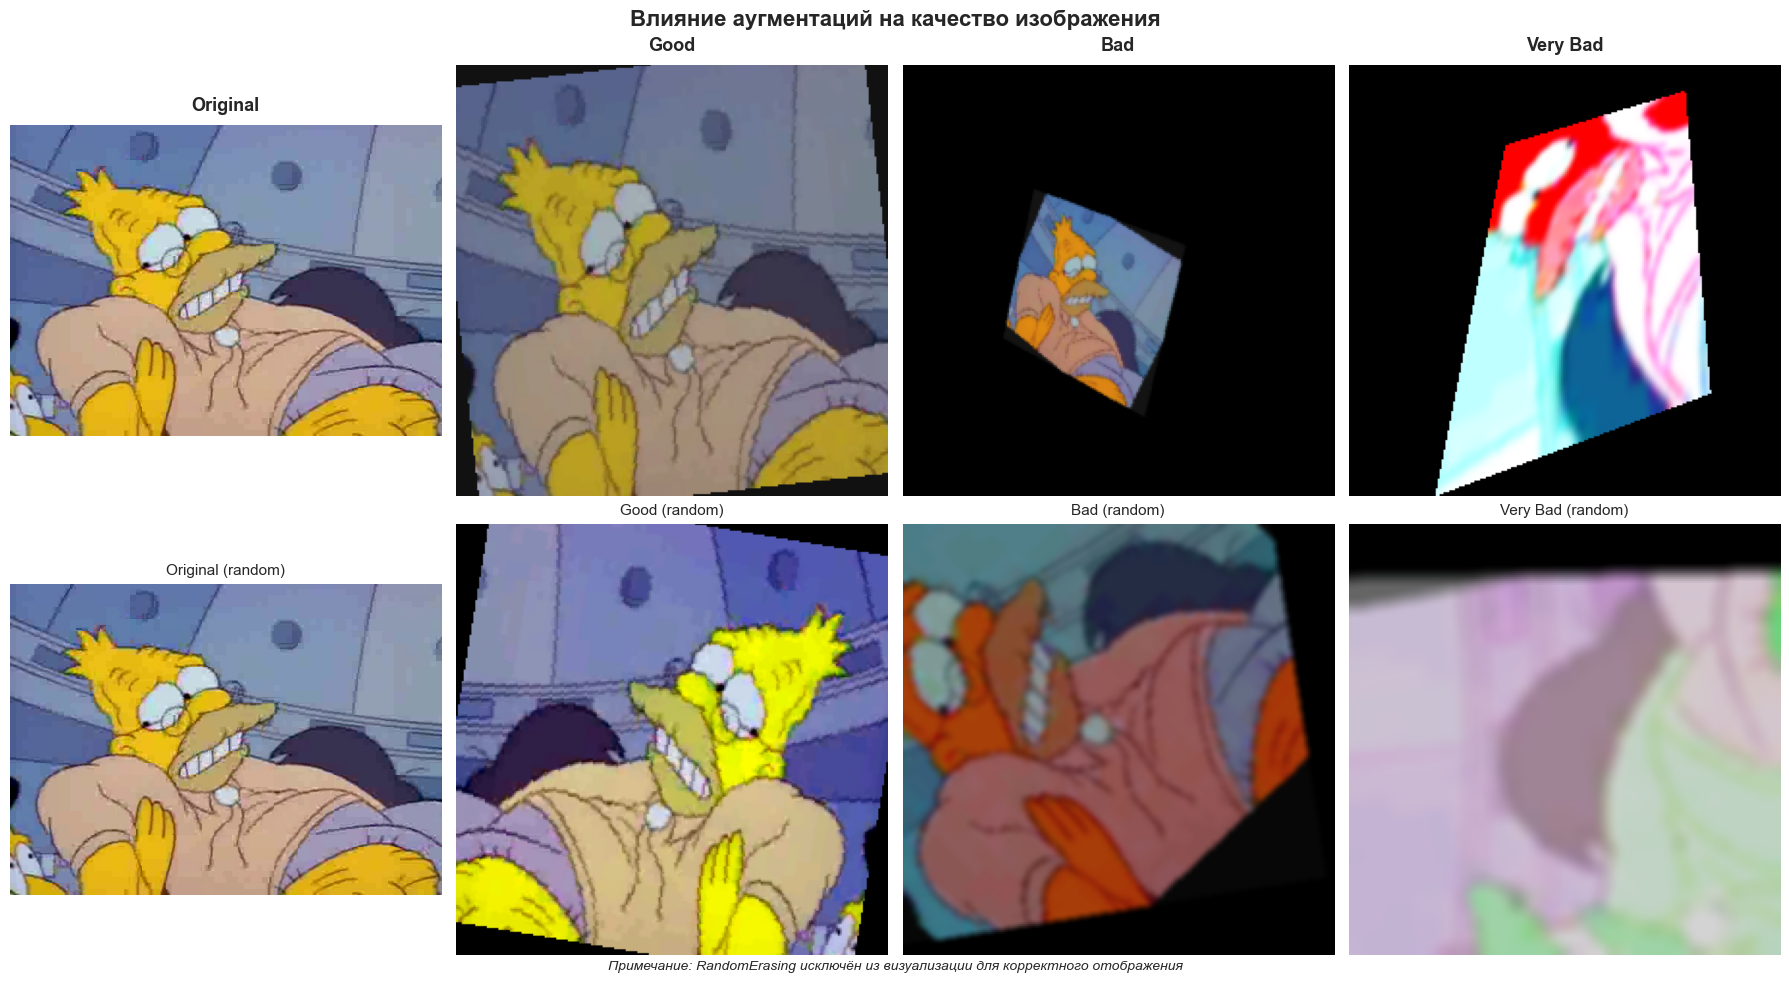

✅ Визуализация завершена!


In [9]:
# ============================================
# 4 ПАРАМЕТРЫ ОБУЧЕНИЯ И АУГМЕНТАЦИИ
# ============================================

# Параметры обучения
BATCH_SIZE = 64
NUM_EPOCHS = 1
LEARNING_RATE = 0.001
IMG_SIZE = 224
NUM_WORKERS = 2

# Нормализация для ImageNet
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# ============================================
# 1. Базовые аугментации (хорошие)
# ============================================
train_transforms_good = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# ============================================
# 2. Плохие аугментации (сильно ухудшающие качество)
# ============================================
train_transforms_bad = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),  # Слишком большой угол
    transforms.ColorJitter(brightness=0.8, contrast=0.8, saturation=0.8, hue=0.4),  # ИСПРАВЛЕНО: hue=0.4 (было 0.8)
    transforms.RandomAffine(degrees=30, translate=(0.3, 0.3), scale=(0.5, 1.5)),  # Сильные искажения
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 3.0)),  # Размытие
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5),  # Искажение перспективы
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# ============================================
# 3. Очень плохие аугментации (экстремальные)
# ============================================
train_transforms_very_bad = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),  # Вертикальный переворот для персонажей
    transforms.RandomRotation(degrees=90),  # Очень большой угол
    transforms.ColorJitter(brightness=1.5, contrast=1.5, saturation=1.5, hue=0.5),  # ИСПРАВЛЕНО: hue=0.5 (максимум)
    transforms.RandomAffine(degrees=45, translate=(0.5, 0.5), scale=(0.3, 2.0)),
    transforms.GaussianBlur(kernel_size=11, sigma=(0.5, 5.0)),
    transforms.RandomPerspective(distortion_scale=0.8, p=0.8),
    transforms.RandomErasing(p=0.5, scale=(0.2, 0.4)),  # Случайное стирание частей
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# ============================================
# Валидационные трансформации (без аугментаций)
# ============================================
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

print("✅ Аугментации успешно определены!")
print(f"   Good: {len(train_transforms_good.transforms)} трансформаций")
print(f"   Bad: {len(train_transforms_bad.transforms)} трансформаций")
print(f"   Very Bad: {len(train_transforms_very_bad.transforms)} трансформаций")

# ============================================
# ДЕТАЛЬНАЯ ВИЗУАЛИЗАЦИЯ С ОПИСАНИЕМ
# ============================================

def visualize_augmentations_detailed():
    """Детальная визуализация с описанием эффектов"""

    # Получаем изображение
    sample_class = os.listdir(TRAIN_DIR)[0]
    sample_img_path = os.path.join(TRAIN_DIR, sample_class,
                                   os.listdir(os.path.join(TRAIN_DIR, sample_class))[0])
    original_img = Image.open(sample_img_path).convert('RGB')

    # Описания аугментаций
    descriptions = {
        "Original": "Исходное изображение без изменений",
        "Good": "Умеренные аугментации:\n- Горизонтальный переворот (50%)\n- Вращение ±10°\n- Небольшое изменение цвета",
        "Bad": "Сильные аугментации:\n- Вращение ±45°\n- Сильное изменение цвета\n- Размытие\n- Искажение перспективы",
        "Very Bad": "Экстремальные аугментации:\n- Вращение ±90°\n- Вертикальный переворот\n- Очень сильное изменение цвета\n- Случайное стирание частей"
    }

    # Трансформации без RandomErasing для визуализации
    transforms_list = [
        ("Original", None, descriptions["Original"]),
        ("Good", train_transforms_good, descriptions["Good"]),
        ("Bad", transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=45),
            transforms.ColorJitter(brightness=0.8, contrast=0.8, saturation=0.8, hue=0.4),
            transforms.RandomAffine(degrees=30, translate=(0.3, 0.3), scale=(0.5, 1.5)),
            transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 3.0)),
            transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ]), descriptions["Bad"]),
        ("Very Bad", transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=90),
            transforms.ColorJitter(brightness=1.5, contrast=1.5, saturation=1.5, hue=0.5),
            transforms.RandomAffine(degrees=45, translate=(0.5, 0.5), scale=(0.3, 2.0)),
            transforms.GaussianBlur(kernel_size=11, sigma=(0.5, 5.0)),
            transforms.RandomPerspective(distortion_scale=0.8, p=0.8),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std)
        ]), descriptions["Very Bad"])
    ]

    fig, axes = plt.subplots(2, 4, figsize=(18, 10))

    # Первая строка
    for idx, (name, transform, desc) in enumerate(transforms_list):
        ax = axes[0, idx]

        if transform is None:
            display_img = original_img
        else:
            transformed = transform(original_img)
            display_img = transformed * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
            display_img = torch.clamp(display_img, 0, 1)
            display_img = transforms.ToPILImage()(display_img)

        ax.imshow(display_img)
        ax.set_title(name, fontsize=13, fontweight='bold', pad=10)
        ax.axis('off')

    # Вторая строка - случайное применение
    for idx, (name, transform, desc) in enumerate(transforms_list):
        ax = axes[1, idx]

        if transform is None:
            display_img = original_img
        else:
            transformed = transform(original_img)
            display_img = transformed * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
            display_img = torch.clamp(display_img, 0, 1)
            display_img = transforms.ToPILImage()(display_img)

        ax.imshow(display_img)
        ax.set_title(f"{name} (random)", fontsize=11)
        ax.axis('off')

    plt.suptitle('Влияние аугментаций на качество изображения',
                 fontsize=16, fontweight='bold', y=0.98)

    # Добавляем общее описание
    fig.text(0.5, 0.02,
             'Примечание: RandomErasing исключён из визуализации для корректного отображения',
             ha='center', fontsize=10, style='italic')

    plt.tight_layout()
    plt.show()

# Запуск детальной визуализации
print("🖼️ Генерация детальной визуализации...")
visualize_augmentations_detailed()
print("✅ Визуализация завершена!")

Всего классов: 43
Всего изображений: 5921
Среднее количество изображений на класс: 137.7
Минимум: 3, Максимум: 1194


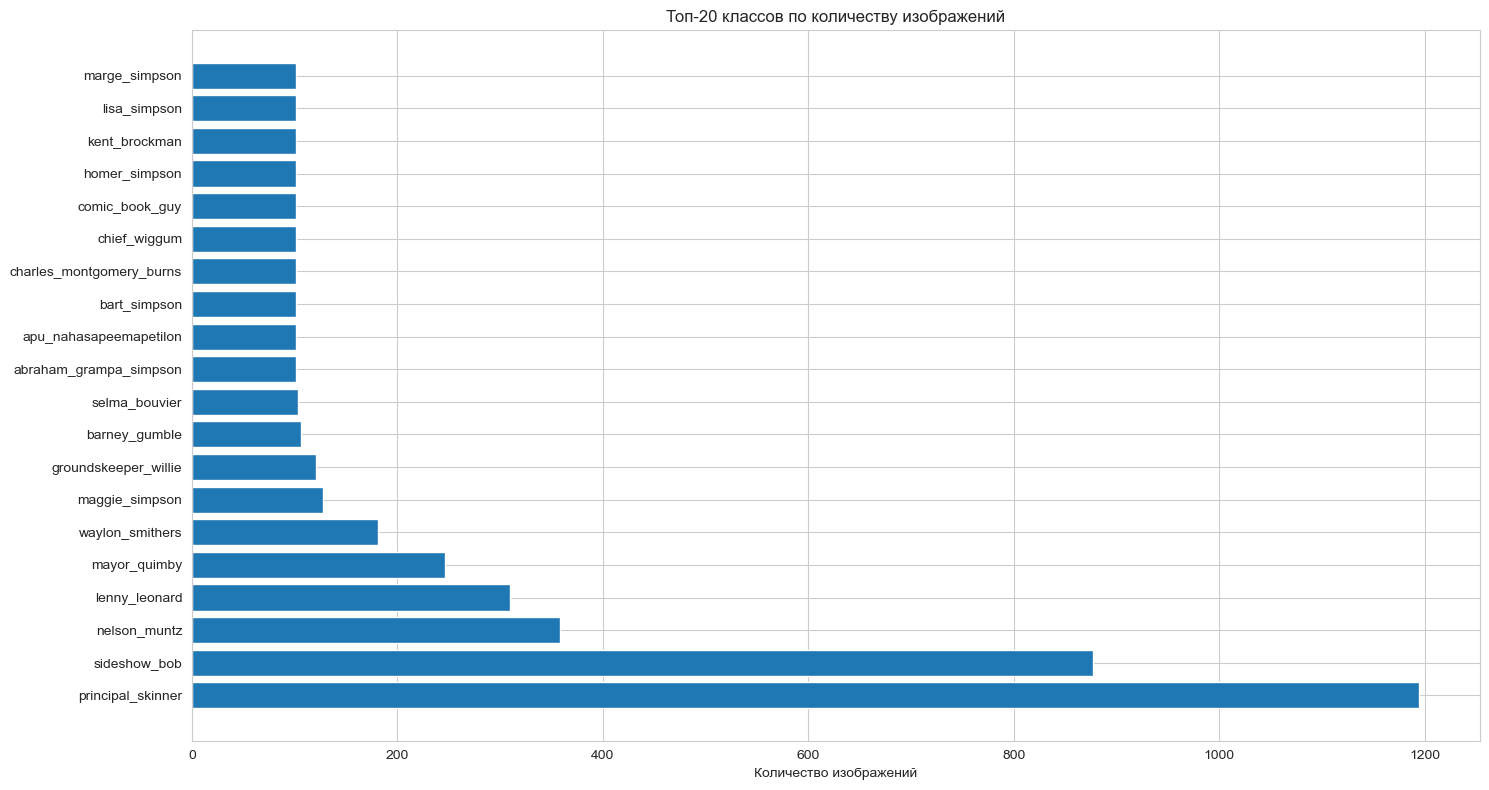


Количество классов: 43
Пример классов: ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson']


In [10]:
# ============================================
# 5 DATASET И DATALOADER
# ============================================

class SimpsonsDataset(Dataset):
    """Кастомный Dataset для Симпсонов"""

    def __init__(self, root_dir, transform=None, class_to_idx=None):
        self.root_dir = root_dir
        self.transform = transform
        self.class_to_idx = class_to_idx
        self.samples = []
        self._load_samples()

    def _load_samples(self):
        """Загружает пути к изображениям и метки"""
        for class_name in os.listdir(self.root_dir):
            class_path = os.path.join(self.root_dir, class_name)
            if os.path.isdir(class_path):
                class_idx = self.class_to_idx[class_name]
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(class_path, img_name)
                        self.samples.append((img_path, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label


# ============================================
# ИНИЦИАЛИЗАЦИЯ КЛАССОВ
# ============================================

# Анализ распределения классов
def analyze_dataset():
    """Анализирует распределение классов в датасете"""
    class_counts = {}
    total_images = 0

    for class_name in os.listdir(TRAIN_DIR):
        class_path = os.path.join(TRAIN_DIR, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            class_counts[class_name] = num_images
            total_images += num_images

    # Сортировка по количеству
    sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

    print(f"Всего классов: {len(class_counts)}")
    print(f"Всего изображений: {total_images}")
    print(f"Среднее количество изображений на класс: {total_images/len(class_counts):.1f}")
    print(f"Минимум: {min(class_counts.values())}, Максимум: {max(class_counts.values())}")

    # Визуализация
    plt.figure(figsize=(15, 8))
    classes, counts = zip(*sorted_classes[:20])
    plt.barh(range(len(classes)), counts)
    plt.yticks(range(len(classes)), classes)
    plt.xlabel('Количество изображений')
    plt.title('Топ-20 классов по количеству изображений')
    plt.tight_layout()
    plt.show()

    return class_counts

class_counts = analyze_dataset()

# Получение списка классов
class_names = sorted(os.listdir(TRAIN_DIR))
num_classes = len(class_names)
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

print(f"\nКоличество классов: {num_classes}")
print(f"Пример классов: {class_names[:5]}")


def create_datasets(train_transform):
    """Создает train и validation датасеты"""
    all_samples = []
    for class_name in class_names:
        class_path = os.path.join(TRAIN_DIR, class_name)
        class_idx = class_to_idx[class_name]
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_path, img_name)
                all_samples.append((img_path, class_idx))

    # Разделение
    train_samples, val_samples = train_test_split(
        all_samples,
        test_size=0.2,
        stratify=[s[1] for s in all_samples],
        random_state=42
    )

    print(f"Train samples: {len(train_samples)}")
    print(f"Val samples: {len(val_samples)}")

    train_dataset = SimpsonsDataset(TRAIN_DIR, transform=train_transform, class_to_idx=class_to_idx)
    train_dataset.samples = train_samples

    val_dataset = SimpsonsDataset(TRAIN_DIR, transform=val_transforms, class_to_idx=class_to_idx)
    val_dataset.samples = val_samples

    return train_dataset, val_dataset


def create_dataloaders(train_dataset, val_dataset):
    """Создает DataLoader'ы"""
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    return train_loader, val_loader

In [11]:
# ============================================
# 6 ОПРЕДЕЛЕНИЕ МОДЕЛЕЙ
# ============================================

def get_model(model_name: str, num_classes: int, pretrained: bool = True):
    """Возвращает модель с предобученными весами"""
    try:
        from torchvision.models import (
            VGG16_Weights, VGG16_BN_Weights,
            EfficientNet_B0_Weights,
            MobileNet_V3_Small_Weights,
        )
        weights_available = True
    except Exception:
        weights_available = False
        VGG16_Weights = VGG16_BN_Weights = EfficientNet_B0_Weights = MobileNet_V3_Small_Weights = None

    if model_name == 'vgg16':
        if pretrained and weights_available:
            weights = VGG16_Weights.IMAGENET1K_V1
            model = vgg16(weights=weights)
        else:
            model = vgg16(weights=None)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif model_name == 'vgg16_bn':
        if pretrained and weights_available:
            weights = VGG16_BN_Weights.IMAGENET1K_V1
            model = vgg16_bn(weights=weights)
        else:
            model = vgg16_bn(weights=None)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif model_name == 'efficientnet_b0':
        if pretrained and weights_available:
            weights = EfficientNet_B0_Weights.IMAGENET1K_V1
            model = efficientnet_b0(weights=weights)
        else:
            model = efficientnet_b0(weights=None)
        model.classifier[1] = nn.Linear(1280, num_classes)

    elif model_name == 'mobilenet_v3_small':
        if pretrained and weights_available:
            weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
            model = mobilenet_v3_small(weights=weights)
        else:
            model = mobilenet_v3_small(weights=None)
        model.classifier[3] = nn.Linear(1024, num_classes)

    else:
        raise ValueError(f"Unknown model: {model_name}")

    return model


def freeze_model(model, freeze_until=None):
    """Замораживает слои модели"""
    if freeze_until is None:
        for name, param in model.named_parameters():
            if 'classifier' not in name and 'fc' not in name and 'head' not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True
    else:
        frozen = False
        for name, param in model.named_parameters():
            if freeze_until in name:
                frozen = True
            param.requires_grad = frozen

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())

    print(f"✅ Параметры заморожены:")
    print(f"   Trainable: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
    print(f"   Frozen: {total_params - trainable_params:,} ({100*(total_params-trainable_params)/total_params:.2f}%)")

    return model


def unfreeze_model(model):
    """Размораживает все слои модели"""
    for param in model.parameters():
        param.requires_grad = True
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"✅ Все слои разморожены: {trainable_params:,} параметров")
    return model

print("✅ Функции моделей загружены")

✅ Функции моделей загружены


In [12]:
# ============================================
# 7 LR SCHEDULERS
# ============================================

def get_scheduler(optimizer, scheduler_name, num_epochs):
    """Возвращает LR scheduler по имени"""

    if scheduler_name == 'step':
        scheduler = lr_scheduler.StepLR(
            optimizer,
            step_size=5,
            gamma=0.1
        )
    elif scheduler_name == 'multistep':
        scheduler = lr_scheduler.MultiStepLR(
            optimizer,
            milestones=[5, 10, 13],
            gamma=0.1
        )
    elif scheduler_name == 'exponential':
        scheduler = lr_scheduler.ExponentialLR(
            optimizer,
            gamma=0.9
        )
    elif scheduler_name == 'cosine':
        scheduler = lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=num_epochs
        )
    elif scheduler_name == 'cosine_warm_restart':
        scheduler = lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            T_0=5,
            T_mult=2
        )
    elif scheduler_name == 'reduce_on_plateau':
        scheduler = lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',
            factor=0.1,
            patience=3,
            verbose=True
        )
    elif scheduler_name == 'onecycle':
        scheduler = None  # OneCycleLR используется отдельно
    else:
        scheduler = None

    return scheduler


# Список всех scheduler'ов для эксперимента
scheduler_list = [
    'none',
    'step',
    'multistep',
    'exponential',
    'cosine',
    'cosine_warm_restart',
    'reduce_on_plateau',
    'onecycle'
]

print("✅ LR schedulers загружены")
print(f"   Доступные schedulers: {scheduler_list}")

✅ LR schedulers загружены
   Доступные schedulers: ['none', 'step', 'multistep', 'exponential', 'cosine', 'cosine_warm_restart', 'reduce_on_plateau', 'onecycle']


In [13]:
# ============================================
# 8 ФУНКЦИЯ ОБУЧЕНИЯ
# ============================================

def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, scheduler_name='none', num_epochs=15,
                model_name='model', experiment_name='exp',
                checkpoint_interval=1, resume_from_checkpoint=True):
    """
    Обучает модель с автоматическим восстановлением и сохранением чекпоинтов
    """
    
    # Проверяем наличие обучаемых параметров
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if len(trainable_params) == 0:
        raise ValueError("❌ ОШИБКА: Нет параметров с requires_grad=True!")

    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # История для графиков
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }

    # Для OneCycleLR - корректная инициализация
    if scheduler_name == 'onecycle':
        total_steps = num_epochs * len(train_loader)
        scheduler = lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=LEARNING_RATE,
            total_steps=total_steps,
            pct_start=0.3,
            anneal_strategy='cos',
            div_factor=25.0,
            final_div_factor=10000.0
        )
        print(f"✅ OneCycleLR инициализирован: max_lr={LEARNING_RATE}, total_steps={total_steps}")

    # Автоматическое восстановление
    start_epoch = 0
    if resume_from_checkpoint:
        latest_checkpoint = find_latest_checkpoint(experiment_name)
        if latest_checkpoint:
            print(f"\n🔄 Найден чекпоинт, восстанавливаем обучение...")
            checkpoint = load_checkpoint(latest_checkpoint, model, optimizer, scheduler)
            
            if checkpoint:
                start_epoch = checkpoint['epoch'] + 1
                history = checkpoint['history']
                best_acc = checkpoint['best_acc']
                best_model_wts = checkpoint['best_model_wts']
                
                if start_epoch >= num_epochs:
                    print(f"⚠️  Обучение уже завершено (эпоха {start_epoch} из {num_epochs})")
                    model.load_state_dict(best_model_wts)
                    return model, history, best_acc
                else:
                    print(f"✅ Возобновление с эпохи {start_epoch}/{num_epochs}")

    print(f"\n{'='*70}")
    print(f"🚀 НАЧАЛО ОБУЧЕНИЯ: {experiment_name}")
    print(f"{'='*70}")
    print(f"Модель: {model_name}")
    print(f"Scheduler: {scheduler_name}")
    print(f"Epochs: {start_epoch+1}-{num_epochs}")
    print(f"Обучаемых параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"{'='*70}\n")

    try:
        for epoch in range(start_epoch, num_epochs):
            print(f'Epoch {epoch+1}/{num_epochs}')
            print('-' * 50)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                    dataloader = train_loader
                else:
                    model.eval()
                    dataloader = val_loader

                running_loss = 0.0
                running_corrects = 0

                for inputs, labels in tqdm(dataloader, desc=phase, leave=False):
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()
                            
                            if scheduler_name == 'onecycle' and scheduler is not None:
                                scheduler.step()

                    loss_value = loss.detach().cpu().item()
                    running_loss += loss_value * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data).detach().cpu().item()

                epoch_loss = running_loss / len(dataloader.dataset)
                epoch_acc = running_corrects / len(dataloader.dataset)

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                if phase == 'train':
                    history['train_loss'].append(epoch_loss)
                    history['train_acc'].append(epoch_acc)
                else:
                    history['val_loss'].append(epoch_loss)
                    history['val_acc'].append(epoch_acc)

                    if scheduler_name == 'reduce_on_plateau' and scheduler is not None:
                        scheduler.step(epoch_acc)

                    if epoch_acc > best_acc:
                        best_acc = epoch_acc
                        best_model_wts = copy.deepcopy(model.state_dict())

            if scheduler is not None and scheduler_name not in ['reduce_on_plateau', 'onecycle']:
                scheduler.step()

            current_lr = optimizer.param_groups[0]['lr']
            history['lr'].append(current_lr)
            print(f'Learning Rate: {current_lr:.6f}\n')

            if (epoch + 1) % checkpoint_interval == 0:
                save_checkpoint(
                    model, optimizer, scheduler, epoch, history, best_acc,
                    best_model_wts, experiment_name
                )

        time_elapsed = time.time() - since
        print(f'\n{"="*70}')
        print(f'✅ ОБУЧЕНИЕ ЗАВЕРШЕНО')
        print(f'{"="*70}')
        print(f'Время: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Лучшая точность на валидации: {best_acc:.4f}')
        print(f'{"="*70}\n')

        save_checkpoint(
            model, optimizer, scheduler, num_epochs - 1, history, best_acc,
            best_model_wts, experiment_name, filename=f'final_{experiment_name}.pt'
        )

        model.load_state_dict(best_model_wts)

    except KeyboardInterrupt:
        print(f"\n⚠️  Обучение прервано пользователем на эпохе {epoch+1}")
        save_checkpoint(
            model, optimizer, scheduler, epoch, history, best_acc,
            best_model_wts, experiment_name, filename=f'interrupted_{experiment_name}.pt'
        )
        print("💾 Чекпоинт сохранён. Можно возобновить обучение.")
        raise

    except Exception as e:
        print(f"\n❌ Ошибка при обучении: {e}")
        save_checkpoint(
            model, optimizer, scheduler, epoch, history, best_acc,
            best_model_wts, experiment_name, filename=f'error_{experiment_name}.pt'
        )
        print("💾 Чекпоинт сохранён. Можно возобновить обучение.")
        raise

    return model, history, best_acc

print("✅ Функция обучения загружена")

✅ Функция обучения загружена


In [14]:
# ============================================
# 9 ФУНКЦИИ ВИЗУАЛИЗАЦИИ
# ============================================

def plot_scheduler_results(scheduler_results):
    """Визуализирует результаты эксперимента с scheduler'ами"""
    plt.figure(figsize=(14, 5))
    
    # График accuracy
    plt.subplot(1, 2, 1)
    for scheduler_name, results in scheduler_results.items():
        history = results['history']
        plt.plot(range(1, len(history['val_acc']) + 1), history['val_acc'], 
                label=scheduler_name, marker='o', markersize=3, alpha=0.7)
    plt.title('Validation Accuracy', fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(True, alpha=0.3)

    # График learning rate
    plt.subplot(1, 2, 2)
    for scheduler_name, results in scheduler_results.items():
        history = results['history']
        plt.plot(range(1, len(history['lr']) + 1), history['lr'], 
                label=scheduler_name, marker='o', markersize=3, alpha=0.7)
    plt.title('Learning Rate', fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend(loc='upper right', fontsize=8)
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'scheduler_results.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Bar chart лучших результатов
    plt.figure(figsize=(10, 6))
    sched_names = list(scheduler_results.keys())
    best_accs = [scheduler_results[s]['best_acc'] for s in sched_names]
    colors = plt.cm.viridis(np.linspace(0, 1, len(sched_names)))
    bars = plt.bar(sched_names, best_accs, color=colors, alpha=0.8, edgecolor='black')
    plt.title('Best Accuracy by Scheduler', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy')
    plt.xlabel('Scheduler')
    plt.xticks(rotation=15)
    plt.ylim([min(best_accs) - 0.05, 1.0])
    plt.grid(True, axis='y', alpha=0.3)

    for bar, acc in zip(bars, best_accs):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


def plot_augmentation_results(augmentation_results):
    """Визуализирует результаты эксперимента с аугментациями"""
    plt.figure(figsize=(14, 5))
    
    # График accuracy
    plt.subplot(1, 2, 1)
    for aug_name, results in augmentation_results.items():
        history = results['history']
        plt.plot(range(1, len(history['val_acc']) + 1), history['val_acc'], 
                label=results['description'], linewidth=2, marker='o', markersize=4)
    plt.title('Validation Accuracy', fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # График loss
    plt.subplot(1, 2, 2)
    for aug_name, results in augmentation_results.items():
        history = results['history']
        plt.plot(range(1, len(history['val_loss']) + 1), history['val_loss'], 
                label=results['description'], linewidth=2, marker='o', markersize=4)
    plt.title('Validation Loss', fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'augmentation_results.png'), dpi=300, bbox_inches='tight')
    plt.show()


def plot_architecture_results(architecture_results):
    """Визуализирует результаты эксперимента с архитектурами"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Val accuracy
    ax = axes[0]
    for model_name, results in architecture_results.items():
        history = results['history']
        ax.plot(history['val_acc'], label=results['description'], linewidth=2, marker='o', markersize=4)
    ax.set_title('Validation Accuracy', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axvline(x=NUM_EPOCHS//2, color='red', linestyle='--', alpha=0.5, label='Fine-tuning start')

    # Val loss
    ax = axes[1]
    for model_name, results in architecture_results.items():
        history = results['history']
        ax.plot(history['val_loss'], label=results['description'], linewidth=2, marker='o', markersize=4)
    ax.set_title('Validation Loss', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axvline(x=NUM_EPOCHS//2, color='red', linestyle='--', alpha=0.5, label='Fine-tuning start')

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'architecture_results.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # Сравнение frozen vs fine-tuned
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    models = list(architecture_results.keys())
    frozen_accs = [architecture_results[m]['best_acc_frozen'] for m in models]
    finetune_accs = [architecture_results[m]['best_acc_finetune'] for m in models]
    x = np.arange(len(models))
    width = 0.35

    bars1 = ax.bar(x - width/2, frozen_accs, width, label='Frozen (Phase 1)', alpha=0.8)
    bars2 = ax.bar(x + width/2, finetune_accs, width, label='Fine-tuned (Phase 2)', alpha=0.8)

    ax.set_title('Frozen vs Fine-tuned Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(x)
    ax.set_xticklabels([architecture_results[m]['description'] for m in models], rotation=15)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

print("✅ Функции визуализации загружены")

✅ Функции визуализации загружены


In [ ]:
# ============================================
# 🧪 10 ЭКСПЕРИМЕНТ 1: СРАВНЕНИЕ LR SCHEDULERS
# ============================================

scheduler_results = {}

# Создаем датасеты с хорошими аугментациями
print("📁 Создание датасетов...")
train_dataset, val_dataset = create_datasets(train_transforms_good)
train_loader, val_loader = create_dataloaders(train_dataset, val_dataset)

base_model_name = 'efficientnet_b0'

print(f"\n{'='*70}")
print("🧪 ЭКСПЕРИМЕНТ 1: СРАВНЕНИЕ LR SCHEDULERS")
print(f"{'='*70}\n")

for scheduler_name in scheduler_list:
    print(f"\n{'='*70}")
    print(f"📊 Testing scheduler: {scheduler_name}")
    print(f"{'='*70}\n")

    # Создаем модель
    model = get_model(base_model_name, num_classes, pretrained=True)
    model = freeze_model(model)
    model = model.to(device)

    # Критерий
    criterion = nn.CrossEntropyLoss()

    # Настройка оптимизатора и LR
    if scheduler_name == 'onecycle':
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), 
            lr=LEARNING_RATE / 25
        )
    else:
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), 
            lr=LEARNING_RATE
        )

    # Получаем scheduler
    scheduler = get_scheduler(optimizer, scheduler_name, NUM_EPOCHS)

    # Обучение
    try:
        model, history, best_acc = train_model(
            model, train_loader, val_loader, criterion, optimizer,
            scheduler=scheduler, scheduler_name=scheduler_name,
            num_epochs=NUM_EPOCHS,
            model_name=base_model_name,
            experiment_name=f'scheduler_{scheduler_name}',
            checkpoint_interval=1,
            resume_from_checkpoint=True
        )

        scheduler_results[scheduler_name] = {
            'history': history,
            'best_acc': best_acc
        }

        print(f"✅ Best accuracy with {scheduler_name}: {best_acc:.4f}\n")

    except Exception as e:
        print(f"❌ Ошибка при обучении с {scheduler_name}: {str(e)}\n")
        continue

print(f"\n{'='*70}")
print("📊 РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА 1")
print(f"{'='*70}\n")

# Сортировка результатов по точности
sorted_results = sorted(scheduler_results.items(), key=lambda x: x[1]['best_acc'], reverse=True)

for scheduler_name, results in sorted_results:
    print(f"{scheduler_name:25s}: {results['best_acc']:.4f}")

print(f"\n{'='*70}")

# Визуализация результатов
print("\nГенерация графиков...")
plot_scheduler_results(scheduler_results)

📁 Создание датасетов...
Train samples: 16746
Val samples: 4187

🧪 ЭКСПЕРИМЕНТ 1: СРАВНЕНИЕ LR SCHEDULERS


📊 Testing scheduler: none

✅ Параметры заморожены:
   Trainable: 691,623 (17.02%)
   Frozen: 3,371,008 (82.98%)

🚀 НАЧАЛО ОБУЧЕНИЯ: scheduler_none
Модель: efficientnet_b0
Scheduler: none
Epochs: 1-1
Обучаемых параметров: 691,623

Epoch 1/1
--------------------------------------------------


train:   0%|          | 0/262 [00:00<?, ?it/s]

In [ ]:
# ============================================
# 🧪 11 ЭКСПЕРИМЕНТ 2: ВЛИЯНИЕ АУГМЕНТАЦИЙ НА КАЧЕСТВО
# ============================================

augmentation_configs = [
    ('good', train_transforms_good, "Хорошие аугментации (базовые)"),
    ('bad', train_transforms_bad, "Плохие аугментации (сильные искажения)"),
    ('very_bad', train_transforms_very_bad, "Очень плохие аугментации (экстремальные)"),
]

augmentation_results = {}

# Выбираем лучший scheduler из эксперимента 1
best_scheduler_name = max(scheduler_results.items(), key=lambda x: x[1]['best_acc'])[0]
print(f"Используем лучший scheduler: {best_scheduler_name}\n")

print(f"\n{'='*70}")
print("🧪 ЭКСПЕРИМЕНТ 2: ВЛИЯНИЕ АУГМЕНТАЦИЙ НА КАЧЕСТВО")
print(f"{'='*70}\n")

for aug_name, aug_transform, aug_desc in augmentation_configs:
    print(f"\n{'='*70}")
    print(f"Testing augmentation: {aug_name}")
    print(f"{aug_desc}")
    print(f"{'='*70}\n")

    # Создаем датасеты
    train_dataset, val_dataset = create_datasets(aug_transform)
    train_loader, val_loader = create_dataloaders(train_dataset, val_dataset)

    # Создаем модель
    model = get_model(base_model_name, num_classes, pretrained=True)
    model = freeze_model(model)
    model = model.to(device)

    # Критерий и оптимизатор
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=LEARNING_RATE
    )

    # Scheduler
    scheduler = get_scheduler(optimizer, best_scheduler_name, NUM_EPOCHS)

    # Обучение
    try:
        model, history, best_acc = train_model(
            model, train_loader, val_loader, criterion, optimizer,
            scheduler=scheduler, scheduler_name=best_scheduler_name,
            num_epochs=NUM_EPOCHS,
            model_name=base_model_name,
            experiment_name=f'aug_{aug_name}',
            checkpoint_interval=1,
            resume_from_checkpoint=True
        )

        augmentation_results[aug_name] = {
            'history': history,
            'best_acc': best_acc,
            'description': aug_desc
        }

        print(f"✅ Best accuracy with {aug_name}: {best_acc:.4f}\n")

    except Exception as e:
        print(f"❌ Ошибка при обучении с {aug_name}: {str(e)}\n")
        continue

# Проверка условия: ухудшение более 10%
best_aug_acc = max(augmentation_results.values(), key=lambda x: x['best_acc'])['best_acc']
worst_aug_acc = min(augmentation_results.values(), key=lambda x: x['best_acc'])['best_acc']
acc_drop = (best_aug_acc - worst_aug_acc) / best_aug_acc * 100

print(f"\n{'='*70}")
print(f"📊 Проверка условия ухудшения качества:")
print(f"   Лучшая аугментация: {best_aug_acc:.4f}")
print(f"   Худшая аугментация: {worst_aug_acc:.4f}")
print(f"   Падение качества: {acc_drop:.2f}%")
print(f"   Условие (>10%): {'✅ ВЫПОЛНЕНО' if acc_drop > 10 else '❌ НЕ ВЫПОЛНЕНО'}")
print(f"{'='*70}\n")

# Визуализация результатов
print("\nГенерация графиков...")
plot_augmentation_results(augmentation_results)

In [ ]:
# ============================================
# 🧪 12 ЭКСПЕРИМЕНТ 3: СРАВНЕНИЕ АРХИТЕКТУР
# ============================================

model_list = [
    ('vgg16', "VGG16"),
    ('vgg16_bn', "VGG16-BN"),
    ('efficientnet_b0', "EfficientNet-B0"),
    ('mobilenet_v3_small', "MobileNet-V3-Small"),
]

architecture_results = {}

print(f"\n{'='*70}")
print("🧪 ЭКСПЕРИМЕНТ 3: СРАВНЕНИЕ АРХИТЕКТУР")
print(f"{'='*70}\n")

for model_name, model_desc in model_list:
    print(f"\n{'='*70}")
    print(f"Testing model: {model_name}")
    print(f"{model_desc}")
    print(f"{'='*70}\n")

    # Создаем датасеты
    train_dataset, val_dataset = create_datasets(train_transforms_good)
    train_loader, val_loader = create_dataloaders(train_dataset, val_dataset)

    # Phase 1: Frozen
    print("\n--- Phase 1: Frozen feature extractor ---")
    model = get_model(model_name, num_classes, pretrained=True)
    model = freeze_model(model)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=LEARNING_RATE
    )

    scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS//2)

    try:
        model, history_frozen, best_acc_frozen = train_model(
            model, train_loader, val_loader, criterion, optimizer,
            scheduler=scheduler, scheduler_name='cosine',
            num_epochs=NUM_EPOCHS//2,
            model_name=model_name,
            experiment_name=f'{model_name}_frozen',
            checkpoint_interval=1,
            resume_from_checkpoint=True
        )

        # Phase 2: Fine-tuning
        print("\n--- Phase 2: Fine-tuning all layers ---")
        model = unfreeze_model(model)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE/10)
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS//2        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS//2)

        model, history_finetune, best_acc_finetune = train_model(
            model, train_loader, val_loader, criterion, optimizer,
            scheduler=scheduler, scheduler_name='cosine',
            num_epochs=NUM_EPOCHS//2,
            model_name=model_name,
            experiment_name=f'{model_name}_finetune',
            checkpoint_interval=1,
            resume_from_checkpoint=True
        )

        # Объединяем истории
        combined_history = {
            'train_loss': history_frozen['train_loss'] + history_finetune['train_loss'],
            'train_acc': history_frozen['train_acc'] + history_finetune['train_acc'],
            'val_loss': history_frozen['val_loss'] + history_finetune['val_loss'],
            'val_acc': history_frozen['val_acc'] + history_finetune['val_acc'],
            'lr': history_frozen['lr'] + history_finetune['lr']
        }

        architecture_results[model_name] = {
            'history': combined_history,
            'best_acc_frozen': best_acc_frozen,
            'best_acc_finetune': best_acc_finetune,
            'best_acc': max(best_acc_frozen, best_acc_finetune),
            'description': model_desc
        }

        print(f"✅ {model_name} - Frozen: {best_acc_frozen:.4f}, Fine-tuned: {best_acc_finetune:.4f}\n")

    except Exception as e:
        print(f"❌ Ошибка при обучении {model_name}: {str(e)}\n")
        continue

# Вывод результатов эксперимента 3
print(f"\n{'='*70}")
print("📊 РЕЗУЛЬТАТЫ ЭКСПЕРИМЕНТА 3")
print(f"{'='*70}\n")

print(f"{'Модель':<25} {'Frozen':<10} {'Fine-tuned':<12} {'Улучшение':<10}")
print("-" * 65)

for model_name, results in architecture_results.items():
    improvement = results['best_acc_finetune'] - results['best_acc_frozen']
    print(f"{results['description']:<25} {results['best_acc_frozen']:<10.4f} "
          f"{results['best_acc_finetune']:<12.4f} {improvement:+.4f}")

print(f"{'='*70}")

# Визуализация результатов
print("\nГенерация графиков...")
plot_architecture_results(architecture_results)

In [ ]:
# ============================================
# 📊 13 СВОДНАЯ ВИЗУАЛИЗАЦИЯ ВСЕХ РЕЗУЛЬТАТОВ
# ============================================

def plot_combined_results(scheduler_results, augmentation_results, architecture_results):
    """Сводная визуализация всех экспериментов"""

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3)

    # 1. Лучшие scheduler'ы
    ax1 = fig.add_subplot(gs[0, 0])
    sorted_sched = sorted(scheduler_results.items(), key=lambda x: x[1]['best_acc'], reverse=True)[:5]
    sched_names = [s[0] for s in sorted_sched]
    sched_accs = [s[1]['best_acc'] for s in sorted_sched]
    bars = ax1.barh(sched_names, sched_accs, color=plt.cm.viridis(np.linspace(0, 1, len(sched_names))))
    ax1.set_title('Топ-5 LR Schedulers', fontweight='bold')
    ax1.set_xlabel('Accuracy')
    for i, (bar, acc) in enumerate(zip(bars, sched_accs)):
        ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{acc:.3f}', va='center')

    # 2. Влияние аугментаций
    ax2 = fig.add_subplot(gs[0, 1])
    aug_names = list(augmentation_results.keys())
    aug_accs = [augmentation_results[a]['best_acc'] for a in aug_names]
    aug_desc = [augmentation_results[a]['description'][:20] + '...' for a in aug_names]
    colors = ['green', 'orange', 'red']
    bars = ax2.bar(aug_desc, aug_accs, color=colors, alpha=0.7)
    ax2.set_title('Влияние аугментаций', fontweight='bold')
    ax2.set_ylabel('Accuracy')
    ax2.tick_params(axis='x', rotation=15)
    for bar, acc in zip(bars, aug_accs):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'{acc:.3f}', ha='center', va='bottom')

    # 3. Лучшие архитектуры
    ax3 = fig.add_subplot(gs[0, 2])
    arch_names = list(architecture_results.keys())
    arch_accs = [architecture_results[a]['best_acc'] for a in arch_names]
    arch_desc = [architecture_results[a]['description'][:15] + '...' for a in arch_names]
    bars = ax3.barh(arch_desc, arch_accs, color=plt.cm.plasma(np.linspace(0, 1, len(arch_names))))
    ax3.set_title('Лучшие архитектуры', fontweight='bold')
    ax3.set_xlabel('Accuracy')
    for i, (bar, acc) in enumerate(zip(bars, arch_accs)):
        ax3.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{acc:.3f}', va='center')

    # 4. Сравнение accuracy всех моделей (fine-tuned)
    ax4 = fig.add_subplot(gs[1, :])
    models = list(architecture_results.keys())
    frozen_accs = [architecture_results[m]['best_acc_frozen'] for m in models]
    finetune_accs = [architecture_results[m]['best_acc_finetune'] for m in models]
    x = np.arange(len(models))
    width = 0.35

    bars1 = ax4.bar(x - width/2, frozen_accs, width, label='Frozen (Phase 1)', alpha=0.8)
    bars2 = ax4.bar(x + width/2, finetune_accs, width, label='Fine-tuned (Phase 2)', alpha=0.8)

    ax4.set_title('Сравнение: Frozen vs Fine-tuned', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Accuracy')
    ax4.set_xticks(x)
    ax4.set_xticklabels([architecture_results[m]['description'] for m in models], rotation=15)
    ax4.legend()
    ax4.grid(True, axis='y', alpha=0.3)
    ax4.set_ylim([min(min(frozen_accs), min(finetune_accs)) - 0.05, 1.0])

    # Добавляем значения
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    # 5. Улучшение после fine-tuning
    ax5 = fig.add_subplot(gs[2, :])
    improvements = []
    model_labels = []
    for m in models:
        improvement = architecture_results[m]['best_acc_finetune'] - architecture_results[m]['best_acc_frozen']
        improvements.append(improvement)
        model_labels.append(architecture_results[m]['description'])

    colors = ['green' if imp > 0 else 'red' for imp in improvements]
    bars = ax5.bar(model_labels, improvements, color=colors, alpha=0.7, edgecolor='black')

    ax5.set_title('Улучшение accuracy после Fine-tuning', fontsize=14, fontweight='bold')
    ax5.set_ylabel('Δ Accuracy')
    ax5.set_xlabel('Model')
    ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax5.tick_params(axis='x', rotation=15)
    ax5.grid(True, axis='y', alpha=0.3)

    for bar, imp in zip(bars, improvements):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + (0.002 if height > 0 else -0.002),
                f'{imp:+.3f}', ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'combined_results.png'), dpi=300, bbox_inches='tight')
    plt.show()

# Запуск сводной визуализации
plot_combined_results(scheduler_results, augmentation_results, architecture_results)

In [ ]:
# ============================================
# 💾 14 СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В CSV
# ============================================

def save_results_to_csv(scheduler_results, augmentation_results, architecture_results):
    """Сохраняет результаты в CSV файл"""

    # 1. Scheduler результаты
    scheduler_data = []
    for name, results in scheduler_results.items():
        history = results['history']
        scheduler_data.append({
            'scheduler': name,
            'best_accuracy': results['best_acc'],
            'final_train_acc': history['train_acc'][-1],
            'final_val_acc': history['val_acc'][-1],
            'final_train_loss': history['train_loss'][-1],
            'final_val_loss': history['val_loss'][-1],
            'epochs_trained': len(history['train_acc'])
        })
    
    scheduler_df = pd.DataFrame(scheduler_data)
    scheduler_df = scheduler_df.sort_values('best_accuracy', ascending=False)
    scheduler_df.to_csv(os.path.join(BASE_DIR, 'scheduler_results.csv'), index=False, encoding='utf-8-sig')
    print("✅ Scheduler результаты сохранены в scheduler_results.csv")

    # 2. Augmentation результаты
    augmentation_data = []
    for name, results in augmentation_results.items():
        history = results['history']
        augmentation_data.append({
            'augmentation': name,
            'description': results['description'],
            'best_accuracy': results['best_acc'],
            'final_train_acc': history['train_acc'][-1],
            'final_val_acc': history['val_acc'][-1],
            'final_train_loss': history['train_loss'][-1],
            'final_val_loss': history['val_loss'][-1],
            'epochs_trained': len(history['train_acc'])
        })
    
    augmentation_df = pd.DataFrame(augmentation_data)
    augmentation_df.to_csv(os.path.join(BASE_DIR, 'augmentation_results.csv'), index=False, encoding='utf-8-sig')
    print("✅ Augmentation результаты сохранены в augmentation_results.csv")

    # 3. Architecture результаты
    architecture_data = []
    for name, results in architecture_results.items():
        history = results['history']
        architecture_data.append({
            'model': name,
            'description': results['description'],
            'best_accuracy_frozen': results['best_acc_frozen'],
            'best_accuracy_finetune': results['best_acc_finetune'],
            'best_accuracy': results['best_acc'],
            'improvement': results['best_acc_finetune'] - results['best_acc_frozen'],
            'final_train_acc': history['train_acc'][-1],
            'final_val_acc': history['val_acc'][-1],
            'final_train_loss': history['train_loss'][-1],
            'final_val_loss': history['val_loss'][-1],
            'epochs_trained': len(history['train_acc'])
        })
    
    architecture_df = pd.DataFrame(architecture_data)
    architecture_df.to_csv(os.path.join(BASE_DIR, 'architecture_results.csv'), index=False, encoding='utf-8-sig')
    print("✅ Architecture результаты сохранены в architecture_results.csv")

    # 4. Общая сводка
    summary_data = []
    
    # Лучший scheduler
    best_sched = max(scheduler_results.items(), key=lambda x: x[1]['best_acc'])
    summary_data.append({
        'category': 'Best Scheduler',
        'name': best_sched[0],
        'accuracy': best_sched[1]['best_acc']
    })
    
    # Лучшая аугментация
    best_aug = max(augmentation_results.items(), key=lambda x: x[1]['best_acc'])
    summary_data.append({
        'category': 'Best Augmentation',
        'name': best_aug[0],
        'accuracy': best_aug[1]['best_acc']
    })
    
    # Худшая аугментация (проверка условия ухудшения)
    worst_aug = min(augmentation_results.items(), key=lambda x: x[1]['best_acc'])
    acc_drop = best_aug[1]['best_acc'] - worst_aug[1]['best_acc']
    summary_data.append({
        'category': 'Worst Augmentation',
        'name': worst_aug[0],
        'accuracy': worst_aug[1]['best_acc'],
        'drop_from_best': f"{acc_drop:.2%}"
    })
    
    # Лучшая архитектура
    best_arch = max(architecture_results.items(), key=lambda x: x[1]['best_acc'])
    summary_data.append({
        'category': 'Best Architecture',
        'name': best_arch[0],
        'accuracy': best_arch[1]['best_acc']
    })
    
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_csv(os.path.join(BASE_DIR, 'summary_results.csv'), index=False, encoding='utf-8-sig')
    print("✅ Сводные результаты сохранены в summary_results.csv")

    return scheduler_df, augmentation_df, architecture_df, summary_df

# Запуск сохранения результатов
scheduler_df, augmentation_df, architecture_df, summary_df = save_results_to_csv(
    scheduler_results, augmentation_results, architecture_results
)

# Вывод сводной таблицы
print(f"\n{'='*70}")
print("📊 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print(f"{'='*70}\n")
print(summary_df.to_string(index=False))
print(f"\n{'='*70}")

In [ ]:
# ============================================
# 💾 15 СОХРАНЕНИЕ ЛУЧШИХ МОДЕЛЕЙ
# ============================================

def save_best_models(architecture_results):
    """Сохраняет лучшие модели для каждой архитектуры"""

    models_dir = os.path.join(BASE_DIR, 'best_models')
    os.makedirs(models_dir, exist_ok=True)

    print(f"\n{'='*70}")
    print(f"💾 СОХРАНЕНИЕ ЛУЧШИХ МОДЕЛЕЙ")
    print(f"{'='*70}\n")

    for model_name, results in architecture_results.items():
        # Восстанавливаем модель с лучшими весами
        checkpoint_path = os.path.join(CHECKPOINT_DIR, f'latest_{model_name}_finetune.pt')
        
        if os.path.exists(checkpoint_path):
            # Создаем новую модель
            model = get_model(model_name, num_classes, pretrained=False)
            model = model.to(device)

            # Загружаем лучший чекпоинт
            checkpoint = torch.load(checkpoint_path, map_location=device)
            model.load_state_dict(checkpoint['best_model_wts'])

            # Сохраняем модель
            save_path = os.path.join(models_dir, f'{model_name}_best.pt')
            torch.save(model.state_dict(), save_path)
            
            size_mb = os.path.getsize(save_path) / (1024 * 1024)
            print(f"✅ {model_name:<25} -> {model_name}_best.pt ({size_mb:>6.2f} MB)")
        else:
            print(f"⚠️  Чекпоинт для {model_name} не найден")

    print(f"{'='*70}\n")

# Запуск сохранения моделей
save_best_models(architecture_results)

In [ ]:
# ============================================
# 📊 16 ГЕНЕРАЦИЯ ДЕТАЛЬНЫХ ГРАФИКОВ
# ============================================

def generate_detailed_plots(scheduler_results, augmentation_results, architecture_results):
    """Генерирует детальные графики для отчёта"""

    plots_dir = os.path.join(BASE_DIR, 'plots')
    os.makedirs(plots_dir, exist_ok=True)

    print(f"\n{'='*70}")
    print(f"📊 ГЕНЕРАЦИЯ ДЕТАЛЬНЫХ ГРАФИКОВ")
    print(f"{'='*70}\n")

    # График 1: Все scheduler'ы на одном графике
    plt.figure(figsize=(12, 6))
    for scheduler_name, results in scheduler_results.items():
        history = results['history']
        plt.plot(range(1, len(history['val_acc']) + 1), history['val_acc'], 
                label=scheduler_name, marker='o', markersize=3, alpha=0.7)
    plt.title('Validation Accuracy - Все LR Schedulers', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(plots_dir, 'all_schedulers_accuracy.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ График сохранён: all_schedulers_accuracy.png")

    # График 2: Learning Rate для всех scheduler'ов
    plt.figure(figsize=(12, 6))
    for scheduler_name, results in scheduler_results.items():
        history = results['history']
        plt.plot(range(1, len(history['lr']) + 1), history['lr'], 
                label=scheduler_name, marker='o', markersize=3, alpha=0.7)
    plt.title('Learning Rate Schedules', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.legend(loc='upper right', fontsize=8)
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(plots_dir, 'all_schedulers_lr.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ График сохранён: all_schedulers_lr.png")

    # График 3: Аугментации - подробное сравнение
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Accuracy
    ax = axes[0, 0]
    for aug_name, results in augmentation_results.items():
        history = results['history']
        ax.plot(history['val_acc'], label=results['description'], linewidth=2, marker='o', markersize=4)
    ax.set_title('Validation Accuracy', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Loss
    ax = axes[0, 1]
    for aug_name, results in augmentation_results.items():
        history = results['history']
        ax.plot(history['val_loss'], label=results['description'], linewidth=2, marker='o', markersize=4)
    ax.set_title('Validation Loss', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Train accuracy
    ax = axes[1, 0]
    for aug_name, results in augmentation_results.items():
        history = results['history']
        ax.plot(history['train_acc'], label=results['description'], linewidth=2, marker='o', markersize=4)
    ax.set_title('Training Accuracy', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Train loss
    ax = axes[1, 1]
    for aug_name, results in augmentation_results.items():
        history = results['history']
        ax.plot(history['train_loss'], label=results['description'], linewidth=2, marker='o', markersize=4)
    ax.set_title('Training Loss', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'augmentations_comparison.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ График сохранён: augmentations_comparison.png")

    # График 4: Архитектуры - обучающие кривые
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for model_name, results in architecture_results.items():
        history = results['history']
        color = plt.cm.tab10(list(architecture_results.keys()).index(model_name))
        label = results['description']

        # Val accuracy
        axes[0, 0].plot(history['val_acc'], label=label, color=color, linewidth=2)
        # Val loss
        axes[0, 1].plot(history['val_loss'], label=label, color=color, linewidth=2)
        # Train accuracy
        axes[1, 0].plot(history['train_acc'], label=label, color=color, linewidth=2)
        # Train loss
        axes[1, 1].plot(history['train_loss'], label=label, color=color, linewidth=2)

    axes[0, 0].set_title('Validation Accuracy', fontweight='bold')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axvline(x=NUM_EPOCHS//2, color='red', linestyle='--', alpha=0.5, label='Fine-tuning')

    axes[0, 1].set_title('Validation Loss', fontweight='bold')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axvline(x=NUM_EPOCHS//2, color='red', linestyle='--', alpha=0.5, label='Fine-tuning')

    axes[1, 0].set_title('Training Accuracy', fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axvline(x=NUM_EPOCHS//2, color='red', linestyle='--', alpha=0.5, label='Fine-tuning')

    axes[1, 1].set_title('Training Loss', fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axvline(x=NUM_EPOCHS//2, color='red', linestyle='--', alpha=0.5, label='Fine-tuning')

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'architectures_comparison.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ График сохранён: architectures_comparison.png")

    print(f"{'='*70}\n")

# Запуск генерации графиков
generate_detailed_plots(scheduler_results, augmentation_results, architecture_results)

In [ ]:
# ============================================
# 📋 17 ФИНАЛЬНЫЙ ОТЧЁТ
# ============================================

print("\n" + "="*70)
print("📊 ФИНАЛЬНЫЙ ОТЧЁТ ПО ВСЕМ ЭКСПЕРИМЕНТАМ")
print("="*70 + "\n")

# ==============================
# ЭКСПЕРИМЕНТ 1: LR SCHEDULERS
# ==============================
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("ЭКСПЕРИМЕНТ 1: СРАВНЕНИЕ LR SCHEDULERS")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")

sorted_sched = sorted(scheduler_results.items(), key=lambda x: x[1]['best_acc'], reverse=True)
print(f"{'Scheduler':<20} {'Best Acc':<12} {'Final Train':<12} {'Final Val':<12}")
print("-" * 60)
for name, res in sorted_sched:
    h = res['history']
    print(f"{name:<20} {res['best_acc']:<12.4f} {h['train_acc'][-1]:<12.4f} {h['val_acc'][-1]:<12.4f}")

best_sched = sorted_sched[0]
print(f"\n🏆 Лучший scheduler: {best_sched[0]} с accuracy {best_sched[1]['best_acc']:.4f}\n")

# ==============================
# ЭКСПЕРИМЕНТ 2: АУГМЕНТАЦИИ
# ==============================
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("ЭКСПЕРИМЕНТ 2: ВЛИЯНИЕ АУГМЕНТАЦИЙ НА КАЧЕСТВО")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")

sorted_aug = sorted(augmentation_results.items(), key=lambda x: x[1]['best_acc'], reverse=True)
print(f"{'Augmentation':<15} {'Best Acc':<12} {'Final Train':<12} {'Final Val':<12}")
print("-" * 60)
for name, res in sorted_aug:
    h = res['history']
    desc = res['description'][:25]
    print(f"{desc:<25} {res['best_acc']:<12.4f} {h['train_acc'][-1]:<12.4f} {h['val_acc'][-1]:<12.4f}")

best_aug = sorted_aug[0]
worst_aug = sorted_aug[-1]
acc_drop_pct = ((best_aug[1]['best_acc'] - worst_aug[1]['best_acc']) / best_aug[1]['best_acc']) * 100

print(f"\n🏆 Лучшая аугментация: {best_aug[0]} с accuracy {best_aug[1]['best_acc']:.4f}")
print(f"⚠️  Худшая аугментация: {worst_aug[0]} с accuracy {worst_aug[1]['best_acc']:.4f}")
print(f"📉 Падение качества: {acc_drop_pct:.2f}%")
print(f"{'✅ Условие (>10%) ВЫПОЛНЕНО' if acc_drop_pct > 10 else '❌ Условие (>10%) НЕ ВЫПОЛНЕНО'}\n")

# ==============================
# ЭКСПЕРИМЕНТ 3: АРХИТЕКТУРЫ
# ==============================
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("ЭКСПЕРИМЕНТ 3: СРАВНЕНИЕ АРХИТЕКТУР")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")

print(f"{'Модель':<25} {'Frozen':<10} {'Fine-tuned':<12} {'Улучшение':<10}")
print("-" * 65)

for name, res in architecture_results.items():
    improvement = res['best_acc_finetune'] - res['best_acc_frozen']
    imp_sign = "📈" if improvement > 0 else "📉"
    print(f"{res['description']:<25} {res['best_acc_frozen']:<10.4f} "
          f"{res['best_acc_finetune']:<12.4f} {imp_sign} {improvement:+.4f}")

best_arch = max(architecture_results.items(), key=lambda x: x[1]['best_acc'])
print(f"\n🏆 Лучшая архитектура: {best_arch[0]} с accuracy {best_arch[1]['best_acc']:.4f}\n")

# ==============================
# ОБЩАЯ СВОДКА
# ==============================
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("ОБЩАЯ СВОДКА")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n")

print(f"🏆 Лучший scheduler:  {best_sched[0]:<20} ({best_sched[1]['best_acc']:.4f})")
print(f"🏆 Лучшая аугментация: {best_aug[1]['description']:<20} ({best_aug[1]['best_acc']:.4f})")
print(f"🏆 Лучшая архитектура: {best_arch[1]['description']:<20} ({best_arch[1]['best_acc']:.4f})")
print(f"\n📊 Максимальная достигнутая точность: {max(best_sched[1]['best_acc'], best_aug[1]['best_acc'], best_arch[1]['best_acc']):.4f}")

print("\n" + "="*70)
print("✅ ВСЕ ЭКСПЕРИМЕНТЫ ЗАВЕРШЕНЫ")
print("="*70)

In [ ]:
# ============================================
# 📁 18 СПИСОК ВСЕХ ЧЕКПОИНТОВ
# ============================================

list_checkpoints()

Блок	Описание
1-3	Импорты, настройки путей, модуль чекпоинтов
4-5	Параметры обучения и создание DataLoader'ов
6-8	Модели, schedulers, функция обучения
9	Вспомогательные функции визуализации
10	Эксперимент 1: Сравнение LR Schedulers
11	Эксперимент 2: Влияние аугментаций
12	Эксперимент 3: Сравнение архитектур
13-16	Визуализация и сохранение результатов
17	Финальный отчёт
18	Список чекпоинтов